Инициализация

дополнительно отмечу, какие графики с применением чего были сделаны
**Matplotlib**
1.  **№1. Доволен ли пользователь рекомендациями?**
2.  **№2. Активные и Пассивные пользователи**
4.  **№9. Кто платит, но не пользуется?**
5.  **№14. Какая платформа теряет пользователей?**
6.  **№7. Меньшинство самых активных**

**Seaborn**
1.  **№4. Кто платит за музыку?**
2.  **№6. Кто активнее: мужчины или женщины?**
3.  **№10. Кто уходит и почему?**
4.  **№13. Кто на чем сидит?**
5.  **№15. Гендерный выбор тарифа**

**Plotly**
1.  **№3. Как разные поколения реагируют на рекламу?** 
2.  **№5. Где наши рекомендации не работают?**
3.  **№8. Почему студенты уходят?**
4.  **№11. Гендерный баланс по странам**
5.  **№12. Где наша аудитория?**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


# стиль для Matplotlib и Seaborn
sns.set_style("whitegrid", {
    "axes.facecolor": "#F5F5F5",
    "figure.facecolor": "#FFFFFF",
    "grid.color": "#E0E0E0",
    "axes.edgecolor": "#BDBDBD",
    "axes.labelcolor": "#424242",
    "xtick.color": "#616161",
    "ytick.color": "#616161",
    "text.color": "#212121"
})
# увеличиваем размер шрифта 
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 7)})



# загружаем датасет
df = pd.read_csv('spotify_churn_dataset.csv')


# возрастные группы для сегментации
bins = [15, 24, 39, 59]
labels = ['16-24 (Молодежь)', '25-39 (Взрослые)', '40+ (Зрелые)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

# бинарный флаг платящего пользователя
df['is_paid'] = df['subscription_type'].apply(lambda x: 'Платный' if x != 'Free' else 'Бесплатный')

# проверка
print("Данные успешно загружены и подготовлены. Первые 5 строк:")
display(df.head())

Данные успешно загружены и подготовлены. Первые 5 строк:


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned,age_group,is_paid
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1,40+ (Зрелые),Бесплатный
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0,25-39 (Взрослые),Платный
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1,25-39 (Взрослые),Платный
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0,16-24 (Молодежь),Платный
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1,25-39 (Взрослые),Платный


Далее идут сами графики
Все сделано в формате
- идея
- график
- вывод

### 1. Доволен ли пользователь рекомендациями?

*   **Идея:** хочу посмотреть на взаимосвязь между  `skip_rate` и `songs_played_per_day`. `skip_rate` будет ось X, `songs_played_per_day` будет ось Y, а точки на графике будут зависеть от `is_churned` (цвет точек).
*   **Зачем мне это?** `skip_rate` — один из показателей того, насколько пользователю нравятся предлагаемые песни (ну либо он ищет новые треки). Я хочу посмотреть, может есть кластер ушедших пользователей, у которых был высокий `skip_rate` при среднем или даже высоком количестве прослушиваний.


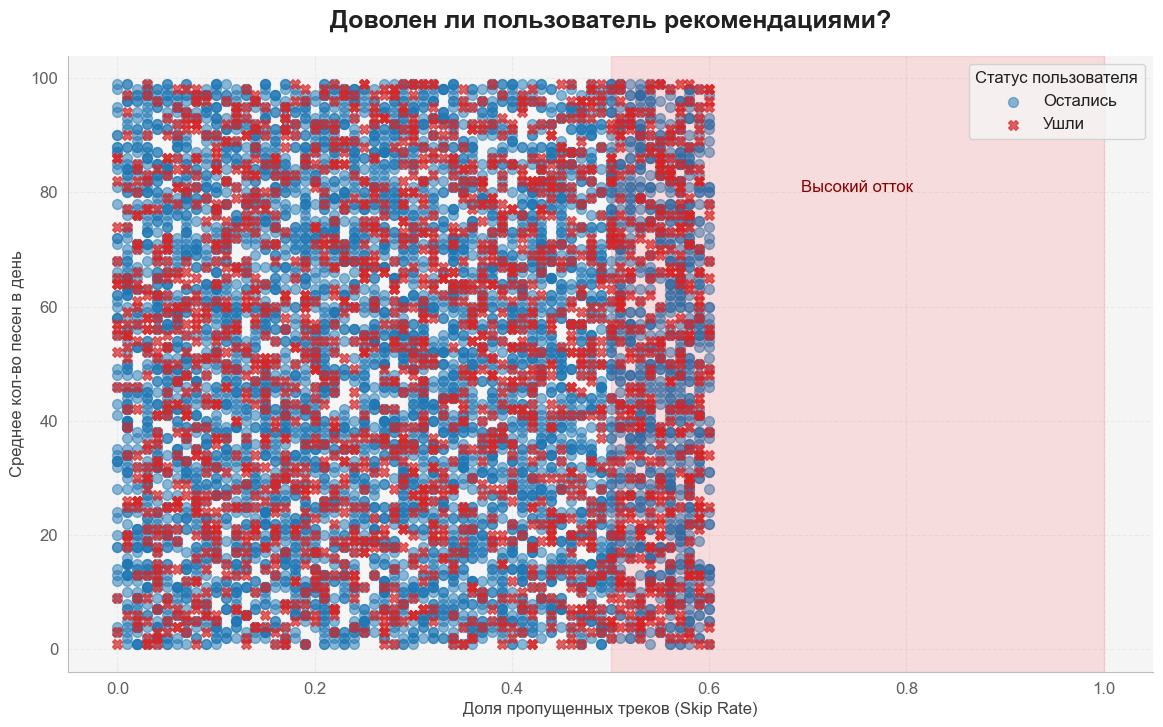

In [22]:
# --- Подготовка данных ---

'''
сделаем выборку из всех пользователей
'''
# этот код сделает выборку из случайных 2000
# df_sample = df.sample(n=2000)
df_sample = df.head(len(df)) # возьмем все записи из файла


'''
разобьем выборку на две группы
- те, кто ушел
- те, кто остались
'''
churned = df_sample[df_sample['is_churned'] == 1]
stayed = df_sample[df_sample['is_churned'] == 0]


# --- График ---

# инициализируем "холст" (fig) и "область для рисования" (ax) с помощью Matplotlib
fig, ax = plt.subplots(figsize=(14, 8)) # figsize=(14, 8) задает размер будущего графика в дюймах (ширина x высота)

# наносим на область 'ax' точки, соответствующие оставшимся пользователям
ax.scatter(
        stayed['skip_rate'], # ось X
        stayed['songs_played_per_day'], # ось Y
        alpha=0.5, # устанавливает полупрозрачность, чтобы были видны скопления точек.
        color='#1F77B4', # задает цвет
        label='Остались', # цекст легенды 
        s=50 # размер точек
        )

# делаем все тоже самое, только для ушедших пользователей
ax.scatter(
        churned['skip_rate'], 
        churned['songs_played_per_day'], 
        alpha=0.7, 
        color='#D62728',
        label='Ушли', 
        s=50, 
        marker='X' # меняем форму точки на крестик.
        )


# --- Украшаем ---

# главный заголовок графика
ax.set_title('Доволен ли пользователь рекомендациями?', 
             fontsize=18,
             fontweight='bold', 
             pad=20 # отступ
             )

# подписываем ось X
ax.set_xlabel('Доля пропущенных треков (Skip Rate)', fontsize=12)

# ось Y
ax.set_ylabel('Среднее кол-во песен в день', fontsize=12)

# отображение легенды, она была определена в параметрах 'label' у функций scatter
ax.legend(title='Статус пользователя')

# добавляем на фон графика сетку
ax.grid(
        True, 
        linestyle='--', # делает ее пунктирной
        alpha=0.6 # делает ее полупрозрачной
        )

# убираем верхнюю и правую рамки графика
ax.spines[['top', 'right']].set_visible(False)

# выделяем на графике область от 0.5 до 1.0 по skipe_rate
ax.axvspan(
        0.5, 
        1.0, 
        color='red', 
        alpha=0.1, 
        label='Высокий отток')

# добавляем текстовую аннотацию
ax.text(
        # координаты
        0.75, 
        80, 
        'Высокий отток', # сама надпись
        ha='center', # выравниваем по центру
        fontsize=12, 
        color='darkred'
        )

# отображаем
plt.show()

как мы видем, результат получился равномерный
скажу на перед -- данные в принципе равномерно распределены и "нереальны"

исходя из полученного результата сложно что-то сказать 
ибо -- сколько пользователь не слушал, сколько пользователь не пропускал, получается пока так, что -- он в равной мере уходит/остается

### 2. Активные и Пассивные пользователи

*   **Идея:** хочется посмотреть, выделяется ли две группы пользователей: Активные (слушают много и пропускают много) и Пассивные (слушают много, но переключают мало). для этого я буду использовать те же поля `skip_rate` и `songs_played_per_day`, но без поля `is_churned`. мы сделаем метрику `skip_rate` * `songs_played_per_day`. этот индекс будет высоким у тех, кто много слушает и много переключает (активничает), и низким у тех, кто мало переключает (фоновое прослушивание), даже если они слушают много песен.
*   **Зачем?**
    *   предположим, что у нас выделяются два таких класса пользователей. тогда, мы сможем работать с ними по разному (предлагать особенные рекомендации, больше вкладываться в тот или инной контент, сделать новые фичи, которые будут интересны той или инной группе)

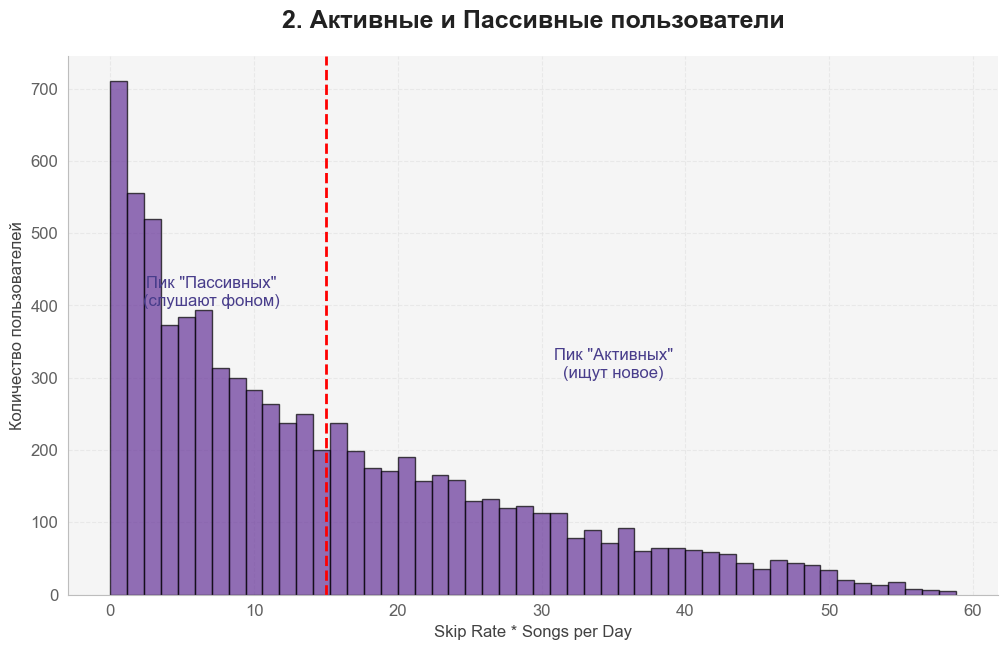

In [25]:
# --- Подготовка данных ---

'''
создаем новую метрику "индекс активности"
она покажет, насколько активно пользователь ищет музыку
(много слушает и много пропускает = высокий индекс)
'''
df['activity_index'] = df['skip_rate'] * df['songs_played_per_day']


# --- График ---

# инициализируем холст и область для рисования
fig, ax = plt.subplots(figsize=(12, 7))

# строим гистограмму
ax.hist(
    df['activity_index'], 
    bins=50, # кол-во столбиков
    color='#663399', # цвет
    edgecolor='black', # цвет обводки
    alpha=0.7 # прозрачность
    )


# --- Украшаем ---

# главный заголовок
ax.set_title(
    '2. Активные и Пассивные пользователи', 
    fontsize=18, 
    fontweight='bold', 
    pad=20 # отступ
    )

# подписываем ось x
ax.set_xlabel('Skip Rate * Songs per Day', fontsize=12)
# подписываем ось y
ax.set_ylabel('Количество пользователей', fontsize=12)

# добавляем сетку на фон
ax.grid(
    True, 
    linestyle='--', # пунктирная линия
    alpha=0.6 # прозрачность
    )

# убираем верхнюю и правую рамки
ax.spines[['top', 'right']].set_visible(False)

# вертикальная линия для разделения
ax.axvline(
    15, 
    color='red', 
    linestyle='--', 
    linewidth=2
    )

# подпись для первого пика ("пассивные")
ax.text(
    7, # координата x
    400, # координата y
    'Пик "Пассивных"\n(слушают фоном)', # текст
    ha='center', # выравнивание
    fontsize=12, 
    color='darkslateblue'
    )

# подпись для второго пика ("активные")
ax.text(
    35, 
    300, 
    'Пик "Активных"\n(ищут новое)', 
    ha='center', 
    fontsize=12, 
    color='darkslateblue'
    )

# отображаем график
plt.show()

как мы видим, у нас много пассивных слушателей
то есть -- имеет смысл вкладываться в контент (плейлисты и тп)
и группа активных пользователей тоже не мала

### 3. Как разные поколения реагируют на рекламу?"

*   **Идея:** хочется посмотреть, как возраст влияет на терпение пользователей мириться с рекламой (сколько нужно рекламы посмотреть, чтобы пользователь решил уйти). для этого воспользуемся полями `age`, `ads_listened_per_week`, `is_churned`, `subscription_type` (фильтрация по 'Free'). проверим предположение, что: молодая аудитория, выросшая на бесплатном контенте, более терпима к рекламе, чем взрослая, которая вероятно ценит свое время выше и не хочет мириться с прерываниями
*   **Зачем?**
    *  мы делим `Free` пользователей на возрастные группы (например, 16-24, 25-39, 40+). Для каждой группы строим график, что показывает распределение `ads_listened_per_week` для ушедших и оставшихся. мы можем увидеть, что в группе 40+ даже при небольшом количестве рекламы отток уже высокий. в то же время в группе 16-24 пользователи спокойно слушают и 40 вставок, и их отток ниже.
    *  если наше предположение будет правильным, то тогда мы можем сделать количество рекламы зависимым от возраста пользователя. (чем моложе, тем рекламы больше. плюс к тому же можно добавить разного рода акции, которые будут показываться в основном у молодых (студенческие скидки, "приведи друга" и тп)). это поможет уменьшить отток новых пользователей

In [33]:
# --- Подготовка данных ---

# фильтруем и оставляем только тех, у кого подписка 'free'
df_free = df[df['subscription_type'] == 'Free'].copy()

# создаем группы для количества рекламы, чтобы сгладить график
bins_ads = np.arange(0, 51, 5) 
# создаем текстовые метки для этих групп
labels_ads = [f'{i}-{i+4}' for i in bins_ads[:-1]]

churn_rate_data = (
    df_free.groupby([ # группируем данные по возрастной группе и по созданным группам рекламы
        'age_group', 
        pd.cut(df_free['ads_listened_per_week'], bins=bins_ads, right=False)
    ])
    .agg( # потом для каждой маленькой группки считаем средний отток (churn_rate) и кол-во пользователей (user_count)
        churn_rate=('is_churned', 'mean'),
        user_count=('user_id', 'count') 
    )
    .reset_index()
)

# для оси X нам нужна одна цифра, а не интервал
# поэтому находим середину каждого интервала
churn_rate_data['ads_bin_center'] = churn_rate_data['ads_listened_per_week'].apply(lambda x: x.mid)

# считаем средний отток по всем бесплатным пользователям
overall_churn_rate = df_free['is_churned'].mean()


# --- График ---

# создаем пустую фигуру
fig = go.Figure()

# создаем палитру цветов для каждой возрастной группы
colors = {
    '16-24 (Молодежь)': '#636EFA',
    '25-39 (Взрослые)': '#EF553B',
    '40+ (Зрелые)': '#00CC96'
}

# запускаем цикл, который нарисует линию для каждой возрастной группы
for group in labels:
    # отбираем данные только для текущей группы
    group_data = churn_rate_data[churn_rate_data['age_group'] == group]
    
    # добавляем на график основную линию с маркерами
    fig.add_trace(go.Scatter(
        x=group_data['ads_bin_center'],
        y=group_data['churn_rate'], 
        mode='lines+markers', # рисовать и линии, и точки
        name=group, # имя для легенды
        line=dict( # настраиваем линию
            color=colors[group], 
            width=3), 
        marker=dict( # настраиваем маркеры
            size=8, 
            color=colors[group], 
            line=dict(
                width=1,
                color='DarkSlateGrey'))
    ))
    
    # добавляем еще один невидимый слой только с текстом
    # нужно, чтобы подписать каждую точку на графике
    fig.add_trace(go.Scatter(
        x=group_data['ads_bin_center'],
        y=group_data['churn_rate'],
        mode='text', # режим: только текст
        name=f'{group}_text', # чтобы не отображалось в легенде
        text=[f'{y:.0%}' for y in group_data['churn_rate']], # сам текст (форматируем в проценты)
        textposition='top center', # положение текста над точкой
        textfont=dict(color=colors[group], size=12, family="Arial Black"), # шрифт текста
        showlegend=False # скрываем из легенды
    ))

# добавляем горизонтальную пунктирную линию, которая показывает средний отток
fig.add_hline(
    y=overall_churn_rate, 
    line_dash="dash", # стиль линии
    line_color="grey", # цвет
    annotation_text=f"Средний отток ({overall_churn_rate:.1%})", # подпись для линии
    annotation_position="bottom right" # положение подписи
    )

# --- Украшаем ---

# добавляем первую аннотацию со стрелкой, которая объясняет поведение молодежи
fig.add_annotation(
    x=45, y=0.17, # куда указывает стрелка
    text="</b><br>Даже при 45+ реклам<br>отток молодежи<br>ниже среднего", # текст
    showarrow=True, # показать стрелку
    arrowhead=2, # стиль стрелки
    arrowcolor="#636EFA", # цвет стрелки
    ax=-60, ay=-40, # смещение текста относительно точки
    font=dict(color="#636EFA"), # цвет текста
    bgcolor="rgba(255,255,255,0.8)" # полупрозрачный фон у текста
)
# добавляем вторую аннотацию для зрелой аудитории
fig.add_annotation(
    x=21, y=0.30,
    text="<br>Зрелая аудитория<br>уходит при малейшем<br>увеличении рекламы",
    showarrow=True, arrowhead=2, arrowcolor="#00CC96", ax=60, ay=-30,
    font=dict(color="#00CC96"), bgcolor="rgba(255,255,255,0.8)"
)


# настраиваем общий вид всего графика
fig.update_layout(
    title_text='<b>3. Как разные поколения реагируют на рекламу?"</b>',
    title_x=0.5, # заголовок по центру
    xaxis_title='Реклам в неделю', # подпись оси x
    yaxis_title='Уровень оттока (Churn Rate)', # подпись оси y
    yaxis_tickformat='.0%', # формат оси y в процентах
    legend_title_text='Возрастная группа', # заголовок легенды
    plot_bgcolor='white', # цвет фона области рисования
    paper_bgcolor='white', # цвет фона всего холста
    font=dict(family="Arial, sans-serif", size=14, color="black"), # общий шрифт
    xaxis=dict(
        showline=True, linewidth=1, linecolor='lightgrey', # линия оси x
        showgrid=True, gridwidth=1, gridcolor='lightgrey', # сетка по x
        griddash='dash'  # стиль сетки - пунктир
    ),
    yaxis=dict(
        showline=True, linewidth=1, linecolor='lightgrey', # линия оси y
        showgrid=True, gridwidth=1, gridcolor='lightgrey', # сетка по y
        griddash='dash'  # стиль сетки - пунктир
    ),
    legend=dict(
        orientation="v", yanchor="top", y=1, xanchor="right", x=1.15, # положение легенды
        bgcolor='rgba(255, 255, 255, 0.5)', bordercolor='grey', borderwidth=1 # стиль легенды
    )
)

# отображаем готовый график
fig.show()

/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_1542/2450751848.py:12: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



вот тут данные показывают себя не так равномерно И даже "как я предпологал"

как мы видим, да -- молодеж более терпелива к рекламе

### 4. Кто платит за музыку?

*   **Идея:** хочу построить портреты пользователей для каждого типа подписки, но по возрасту. для этого возьму `age` и `subscription_type`. хочу проверить, правда ли, что студенты — самые молодые, а семейной подпиской пользуются люди постарше.
*   **Зачем?** если я пойму, какой возраст у каждого тарифа, можно будет точнее настраивать рекламу. например, семейный тариф рекламировать в одноклассниках для людей 35-55 лет, а студенческий — в тиктоке. еще это поможет найти проблемы: если на студенческом тарифе средний возраст 40 лет, значит, что-то не так с проверкой.

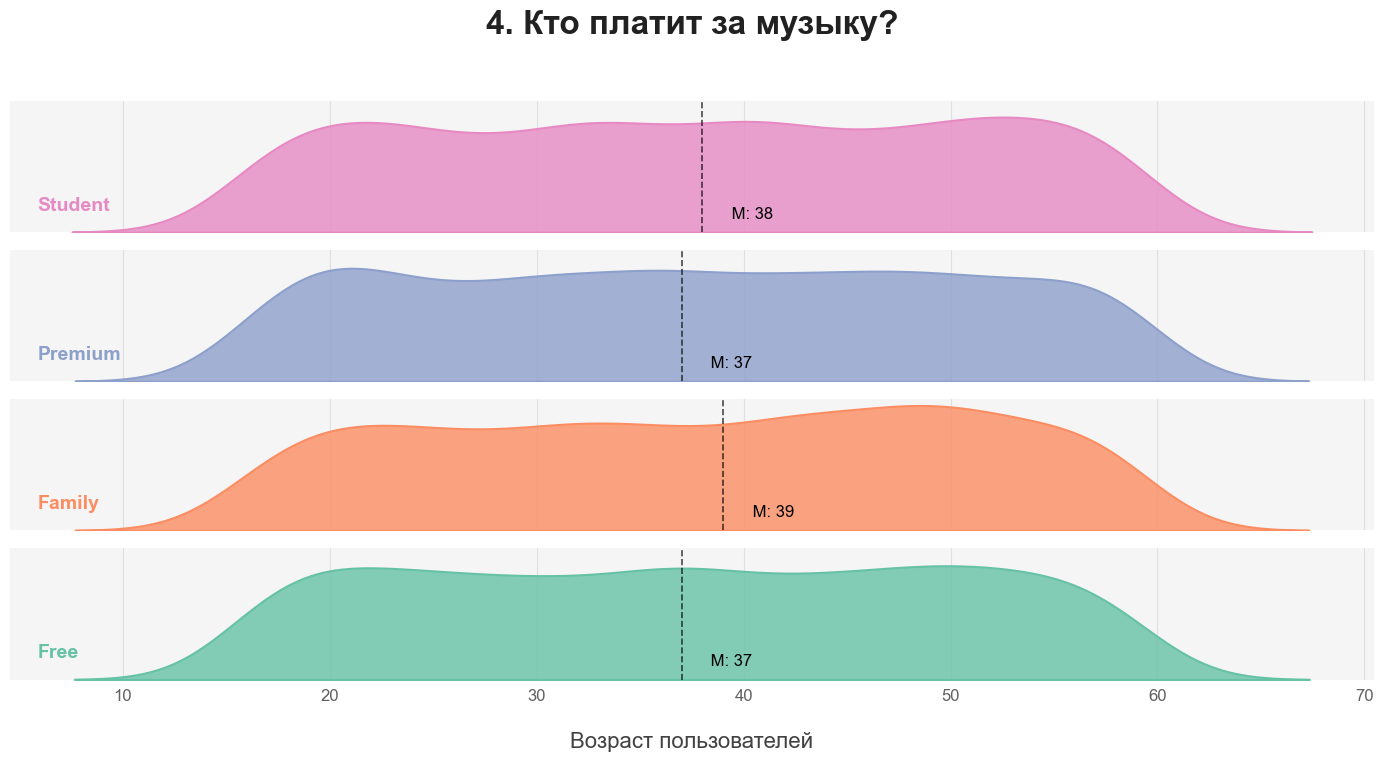

In [43]:
# --- Подготовка данных ---
df_filtered = df.copy()

# задаем порядок, в котором будут идти графики
order = ['Student', 'Premium', 'Family', 'Free']

# создаем палитру цветов для каждой подписки
palette = sns.color_palette("Set2", n_colors=len(order))


# --- график ---

'''
используем ridgeline plot (хребтовый график)
создаем его с помощью FacetGrid
'''
g = sns.FacetGrid(
    df_filtered, 
    row="subscription_type", # каждая строка - отдельный тип подписки
    hue="subscription_type", # у каждой строки свой цвет
    aspect=7, # делаем график широким
    height=2, # и высоким
    palette=palette, # наша палитра
    row_order=order # наш порядок
)

# рисуем сами "горы" (графики плотности)
g.map(
    sns.kdeplot, 
    "age", 
    fill=True, 
    alpha=0.8, 
    linewidth=1.5)

# --- Украшаем ---

'''
теперь добавим на каждый график подписи и линию медианы
'''
def label(x, color, label):
    ax = plt.gca() # получаем доступ к текущему графику
    
    # добавляем название подписки слева
    ax.text(
        0.02, # координата x (слева)
        0.2, # координата y (снизу)
        label, # текст (название подписки)
        fontweight="bold", 
        fontsize=14, 
        color=color,
        ha="left", 
        va="center", 
        transform=ax.transAxes
    )
    
    # считаем и рисуем медиану (средний возраст)
    median_val = df_filtered[df_filtered['subscription_type'] == label]['age'].median()
    ax.axvline(
        median_val, 
        color='black', 
        linestyle='--', 
        linewidth=1.2, 
        alpha=0.7)
    
    ax.text(median_val + 1.2, ax.get_ylim()[1] * 0.1, f' M: {int(median_val)}', color='black', fontsize=12)

# применяем нашу функцию ко всем графикам в сетке
g.map(label, "age")

g.fig.subplots_adjust(hspace=-0.5) # сдвигаем графики друг на друга
g.set_titles("") # убираем стандартные заголовки
g.set(yticks=[], ylabel="") # убираем ось y
g.despine(bottom=True, left=True) # убираем рамки

# добавляем общий заголовок и подпись оси x
plt.xlabel("Возраст пользователей", fontsize=16, labelpad=20) 
g.fig.suptitle(
    "4. Кто платит за музыку?",
    ha='center',
    fontsize=24, 
    fontweight='bold'
)

# подгоняем все элементы, чтобы они не налезали друг на друга
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
# отображаем
plt.show()

данные какие-то равномерные получились

очень странно, что со студенческой подпиской достаточно много пользователей возраста 25+ (чего быть вероятно не должно)

еще необычно, что у Premium большой бугор у молодой части. с одной стороны это вероятно потому, что сервисом вероятно пользуются в основном молодые, с другой -- все равно достаточно необычно


### 5. Где наши рекомендации не работают?

*   **Идея:** хочу нарисовать карту мира и посмотреть, в каких странах рекомендации работают хуже всего. для этого возьму `country`, `skip_rate` и `is_churned`. высокий `skip_rate` в стране может означать, что мы плохо подбираем музыку для местной аудитории.
*   **Зачем?** если в индии (`IN`) высокий `skip_rate` и высокий отток, это сигнал, что алгоритмы не понимают индийскую музыку или тп, из-за чего могут теряться деньги.

In [ ]:
# --- подготовка данных ---

'''
сначала посчитаем нужные цифры для каждой страны:
'''
country_stats = df.groupby('country').agg(
    churn_rate=('is_churned', 'mean'),
    skip_rate=('skip_rate', 'mean'),
    user_count=('user_id', 'count')
).reset_index()

'''
plotly, который рисует карты, понимает только 3-буквенные коды стран (iso)
а у нас в данных 2-буквенные. поэтому нужно их перевести
'''
# создаем словарь для перевода
country_iso_map = {
    'CA': 'CAN', 'DE': 'DEU', 'AU': 'AUS', 'US': 'USA', 
    'UK': 'GBR', 'IN': 'IND', 'FR': 'FRA', 'PK': 'PAK'
}
# создаем новую колонку с 3-буквенными кодами
country_stats['country_iso'] = country_stats['country'].map(country_iso_map)

# --- график ---

'''
рисуем карту мира (choropleth)
'''
fig = px.choropleth(
    country_stats,
    locations="country_iso",  # используем 3-буквенные коды
    color="churn_rate",       # раскрашиваем страны по уровню оттока
    hover_name="country",     # что будет в заголовке при наведении
    hover_data={              # какая еще инфа будет при наведении
        'country_iso': False, # скрыть технический код
        'churn_rate': ':.1%', # отток в процентах
        'skip_rate': ':.1%',  # skip rate в процентах
        'user_count': True    # показать кол-во юзеров
    },
    color_continuous_scale=px.colors.sequential.Reds, # схема: чем выше отток, тем краснее
    labels={ # переименовываем подписи для красоты
        'churn_rate': 'Уровень оттока',
        'skip_rate': 'Средний Skip Rate',
        'user_count': 'Кол-во пользователей',
        'country': 'Страна'
    }
)

# --- украшаем ---

# добавляем заголовок и настраиваем вид
fig.update_layout(
    title_text='<b>5. Где наши рекомендации не работают?</b><br><sup>Чем краснее страна, тем выше процент ушедших пользователей</sup>',
    title_x=0.5, # заголовок по центру
    font=dict(family="Arial, sans-serif", size=14, color="black"),
    geo=dict(
        showframe=False, # убрать рамку вокруг карты
        showcoastlines=False, # убрать линии побережья
        projection_type='natural earth' # тип проекции карты, выглядит красиво
    ),
    coloraxis_colorbar=dict(
        title="Уровень<br>оттока", # заголовок для шкалы цветов
        tickformat=".0%" # формат в процентах
    )
)

# отображаем
fig.show()

вот мы и выявили, где потенциально могут быть проблемы 
- Франция
- Германия
- Пакистан

### 6. Кто активнее: мужчины или женщины?

*   **Идея:** хочу сравнить, кто больше слушает песен в день — мужчины или женщины, но посмотреть это отдельно для каждого тарифа. для этого возьму `songs_played_per_day`, `gender`, `subscription_type`.
*   **Зачем?** это поможет понять, кто самое активное "ядро" на каждом тарифе. если на `Premium` больше слушают мужчины, а на `Free` — женщины, то и рекламу на покупку `Premium` можно нацеливать на мужчин, а кампании по вовлечению на `Free` — на женщин (или наобарот, чтобы привлечь аудиторию противоположного пола)


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_1542/3082763559.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




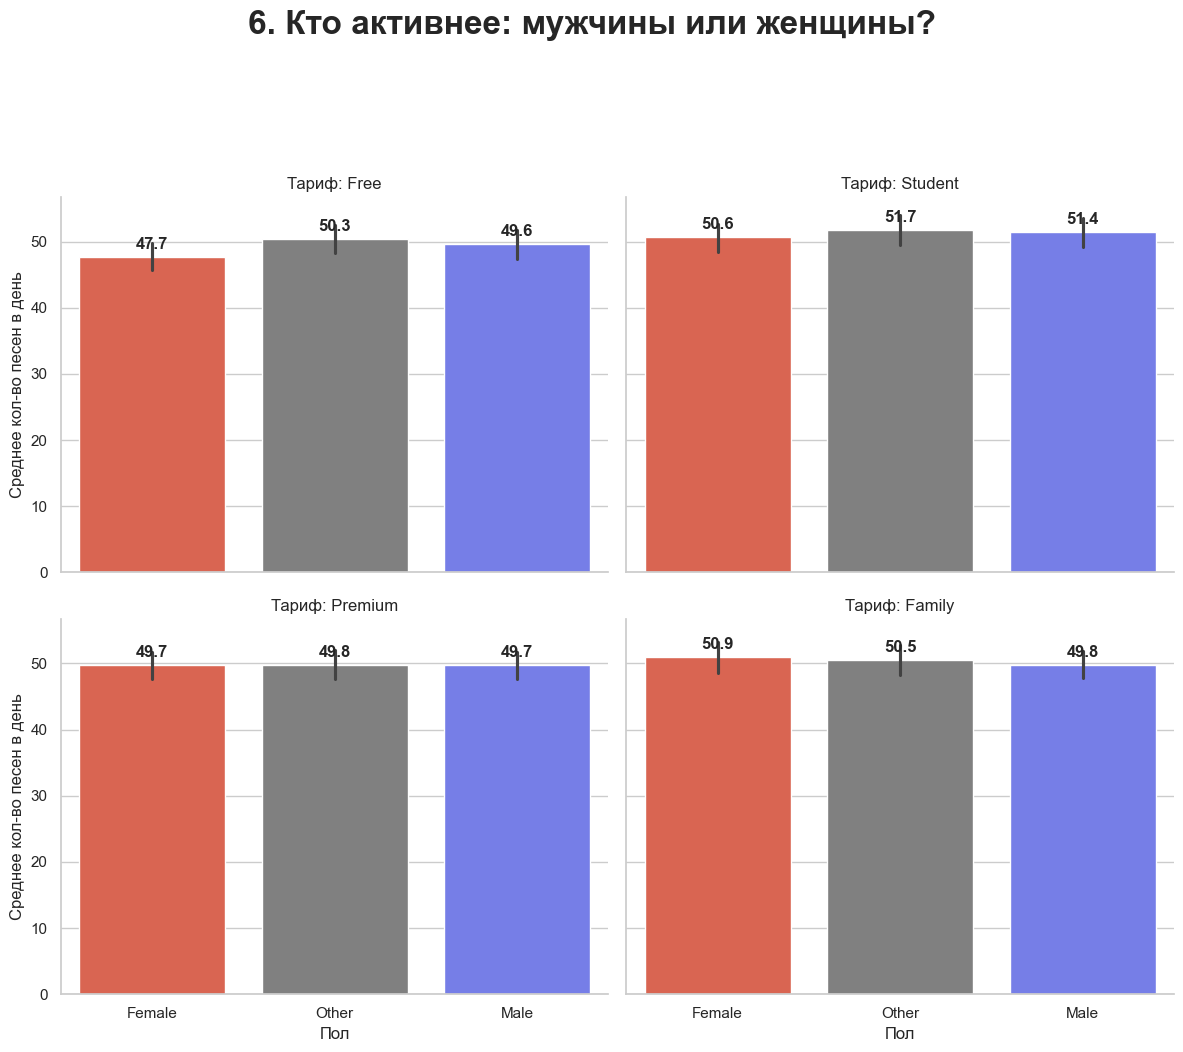

In [ ]:
# --- подготовка данных ---

# --- график ---
g = sns.catplot(
    data=df,
    x='gender', # по оси x - пол
    y='songs_played_per_day', # по оси y - активность
    col='subscription_type', # разделяем на графики по подписке
    col_wrap=2, # по 2 графика в строке
    kind='bar', # тип графика (столбчатая диаграмма)
    palette={'Male': '#636EFA', 'Female': '#EF553B', 'Other': 'grey'}, # наши цвета
    height=5, # высота каждого графика
    aspect=1.2, # соотношение сторон
    col_order=['Free', 'Student', 'Premium', 'Family'] # задаем порядок
)

# --- украшаем ---

# общий заголовок
g.fig.suptitle(
    "6. Кто активнее: мужчины или женщины?",
    fontsize=24,
    fontweight='bold',
    y=1.05
)

# настраиваем подписи осей для всей сетки
g.set_axis_labels("Пол", "Среднее кол-во песен в день")
# настраиваем заголовки каждого маленького графика
g.set_titles("Тариф: {col_name}")

# добавляем подписи данных (цифры на столбцы)
for ax in g.axes.flatten():
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontweight='bold')

# подгоняем элементы
plt.tight_layout(rect=[0, 0, 1, 0.95])
# отображаем
plt.show()

как мы видим, все достаточно равномерно

то есть -- все в равной степени активны по количеству треков

### 7. Меньшинство самых активных

*   **Идея:** найти маленькую группу пользователей, которая моздает большую часть трафика сервиса. для этого возьму `listening_time` и посчитаю вклад разных групп пользователей.
*   **Зачем?** это нужно для оценки рисков. если окажется, что 10% пользователей слушают 70% всей музыки, то уход даже одного такого человека — большая потеря. это значит, что для таких пользователей можно придумать особые условия: VIP-поддержка, особые предложения и тп.

/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_1542/3459963795.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



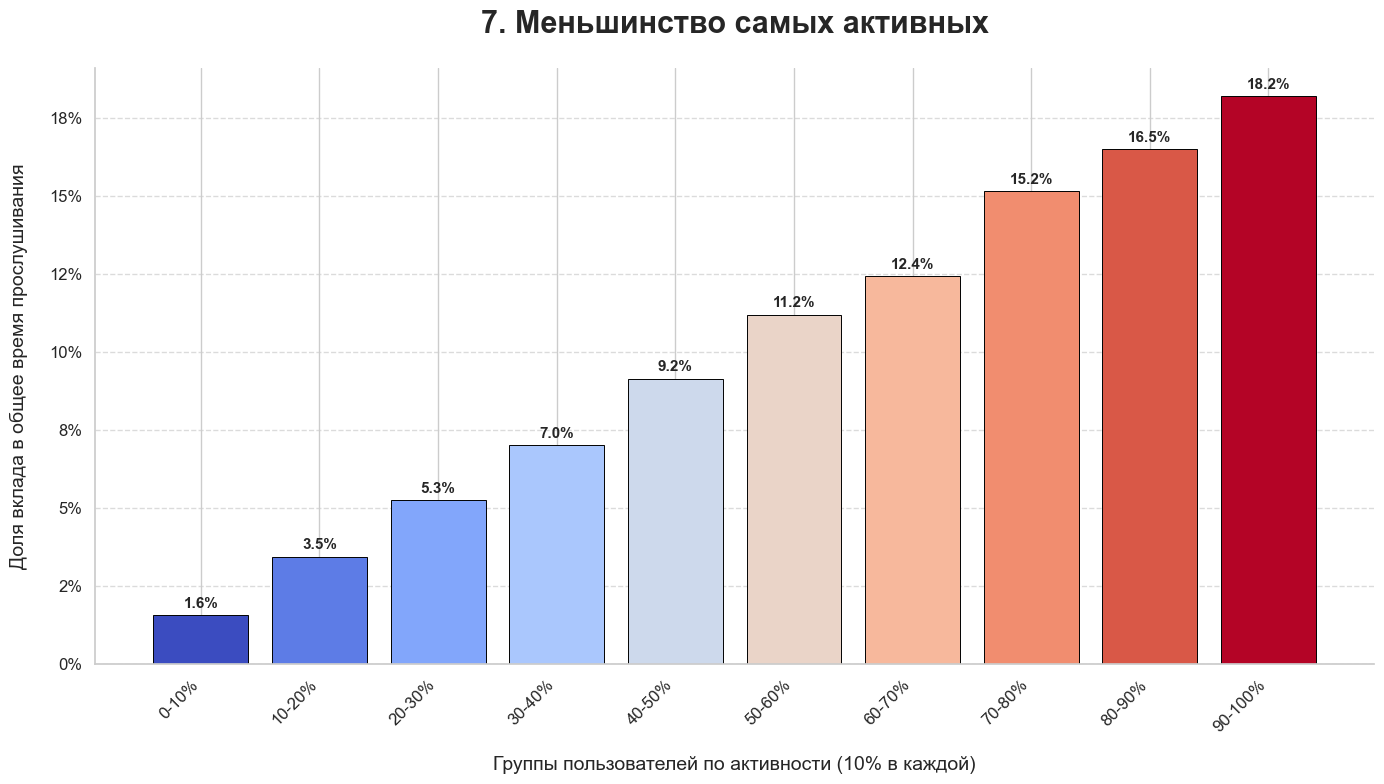

In [67]:
# --- подготовка данных ---

listening_data = df.copy()
'''
делим всех пользователей на 10 равных по количеству групп
то есть -- в первой группе будут самые неактивные 10%, в последней - самые активные 10%
'''
listening_data['activity_decile'] = pd.qcut(
    listening_data['listening_time'], 
    10, # делим на 10 групп
    labels=[f'{i*10}-{i*10+10}%' for i in range(10)] # называем группы 0-10%, 10-20% и т.д.
)

# считаем, сколько всего часов наслушала каждая из 10 групп
decile_contribution = listening_data.groupby('activity_decile')['listening_time'].sum()

# считаем общее время прослушивания по всем пользователям
total_listening = decile_contribution.sum()

# теперь считаем вклад каждой группы в процентах
decile_percentage = (decile_contribution / total_listening) * 100


# --- график ---

# инициализируем холст
fig, ax = plt.subplots(figsize=(14, 8))

'''
рисуем столбчатую диаграмму
используем градиент от синего к красному
'''
colors = plt.cm.coolwarm(np.linspace(0, 1, len(decile_percentage)))

bars = ax.bar(
    decile_percentage.index, # ось x - наши группы
    decile_percentage.values, # ось y - их вклад в %
    color=colors, # цвета
    edgecolor='black',
    linewidth=0.7
)


# --- украшаем ---

# главный заголовок
ax.set_title("7. Меньшинство самых активных", fontsize=22, fontweight='bold', pad=25)
# подписи осей
ax.set_xlabel("Группы пользователей по активности (10% в каждой)", fontsize=14, labelpad=15)
ax.set_ylabel("Доля вклада в общее время прослушивания", fontsize=14, labelpad=15)

# настраиваем ось y, чтобы она показывала проценты
ax.yaxis.set_major_formatter(plt.FuncFormatter('{:.0f}%'.format))
ax.tick_params(axis='both', labelsize=12)

# убираем лишние рамки и добавляем сетку
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # сетка будет под столбиками

# добавляем подписи с точными процентами на каждый столбик
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')

# поворачиваем подписи по оси x для лучшей читаемости
plt.xticks(rotation=45, ha='right')
# автоматически подгоняем элементы, чтобы не было наложений
fig.tight_layout()
# отображаем
plt.show()

как мы видим

у нас есть те самые 30-40% , которые формируют большую часть трафика

### 8. Почему студенты уходят?

*   **Идея:** хочу посмотреть, работает ли что студент оформил себе подписку по дешевле в прошлом, а когда вырос, то не бросил сервис и оформил полный пак. для этого посмотрю на отток в возрасте 22-25 лет, когда обычно заканчивают учебу. воспользуемся `age`, `subscription_type`, `is_churned`.
*   **Зачем?** если мы увидим резкий скачок оттока у `Student`-тарифа в 23 года, то это будет означать, что переход к взрослому `Premium` тарифу не работает. студенты просто уходят, потеряв скидку. это можно учитьвать при предложениях акций для таких пользователей.


In [ ]:
# --- подготовка данных ---

# считаем churn rate для каждой комбинации возраста и типа подписки
churn_by_age_sub = df.groupby(['age', 'subscription_type'])['is_churned'].mean().reset_index()

# считаем кол-во юзеров в каждой группе, чтобы убрать статистически незначимые
user_counts = df.groupby(['age', 'subscription_type'])['user_id'].count().reset_index()
# объединяем две таблицы
churn_by_age_sub = pd.merge(churn_by_age_sub, user_counts, on=['age', 'subscription_type'])
churn_by_age_sub = churn_by_age_sub.rename(columns={'user_id': 'count'})


# --- график ---

# рисуем линейный график с помощью plotly express
fig = px.line(
    churn_by_age_sub,
    x='age', # ось x
    y='is_churned', # ось y
    color='subscription_type', # цвет линии зависит от типа подписки
    markers=True, # добавляем точки на линию
    category_orders={"subscription_type": ["Student", "Premium", "Family", "Free"]}, # задаем порядок в легенде
    color_discrete_map={ # задаем цвета вручную
        "Student": "#EF553B", # красный для акцента на проблеме
        "Premium": "#636EFA",
        "Family": "#00CC96",
        "Free": "#AB63FA"
    },
    labels={ # переименовываем подписи
        'age': 'Возраст пользователя',
        'is_churned': 'Уровень оттока (Churn Rate)',
        'subscription_type': 'Тип подписки'
    }
)


# --- украшаем ---

# добавляем красный прямоугольник, чтобы выделить "критическую зону" 22-25 лет
fig.add_vrect(
    x0="22", 
    x1="25",
    fillcolor="red", 
    opacity=0.1, # прозрачность
    layer="below", # фон под линиями
    line_width=0,
    annotation_text="Критический возраст",
    annotation_position="top left"
)

# добавляем аннотацию со стрелкой, которая указывает на пик
# сначала находим точную точку пика, чтобы стрелка не врала
peak_data = churn_by_age_sub[(churn_by_age_sub['subscription_type'] == 'Student') & (churn_by_age_sub['age'].between(22, 25))]
if not peak_data.empty:
    peak_point = peak_data.loc[peak_data['is_churned'].idxmax()]
    fig.add_annotation(
        x=peak_point['age'], 
        y=peak_point['is_churned'],
        text=f"<b>Пик оттока: {peak_point['is_churned']:.0%}</b><br>Студенты теряют скидку<br>и уходят от нас",
        showarrow=True, 
        arrowhead=2, 
        arrowcolor="#EF553B", 
        ax=-80, 
        ay=-40,
        font=dict(color="black"), 
        bgcolor="rgba(255, 235, 205, 0.8)"
    )

# настраиваем общий вид графика
fig.update_layout(
    title_text='<b>8. Почему студенты уходят?</b><br><sup>Сравнение уровня оттока по возрастам для разных типов подписок</sup>',
    title_x=0.5, # заголовок по центру
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial, sans-serif", size=14, color="black"),
    xaxis=dict(
        showline=True, linewidth=1, linecolor='lightgrey',
        showgrid=True, gridwidth=1, gridcolor='lightgrey',
        griddash='dash',
        range=[15, 60] # ограничиваем ось x, чтобы сфокусироваться на главном
    ),
    yaxis=dict(
        showline=True, linewidth=1, linecolor='lightgrey',
        showgrid=True, gridwidth=1, gridcolor='lightgrey',
        griddash='dash',
        tickformat='.0%' # формат оси y в процентах
    ),
    legend=dict(
        title='Тип подписки',
        orientation="h", # горизонтальная легенда
        yanchor="bottom",
        y=1.02, # положение над графиком
        xanchor="right",
        x=1
    )
)

# отображаем
fig.show()

как мы видим, наше предположение верно


### 9. Кто платит, но не пользуется?
*   **Идея:** хочу найти людей, которые платят за подписку, но ведут себя как бесплатные (например, не используют офлайн-режим). для этого возьму `subscription_type`, `offline_listening` и `is_churned`.
*   **Зачем?** эти люди платят, но не используют одну из главных функций (есть еще add block), которые строят ценность продукта. скорее всего, они скоро уйдут, ибо "а зачем?". если мы найдем этот сегмент, можно будет запустить для них специальную кампанию: либо рассказывать об этой функции, либо придумывать и реализовывать новую, либо и тп.

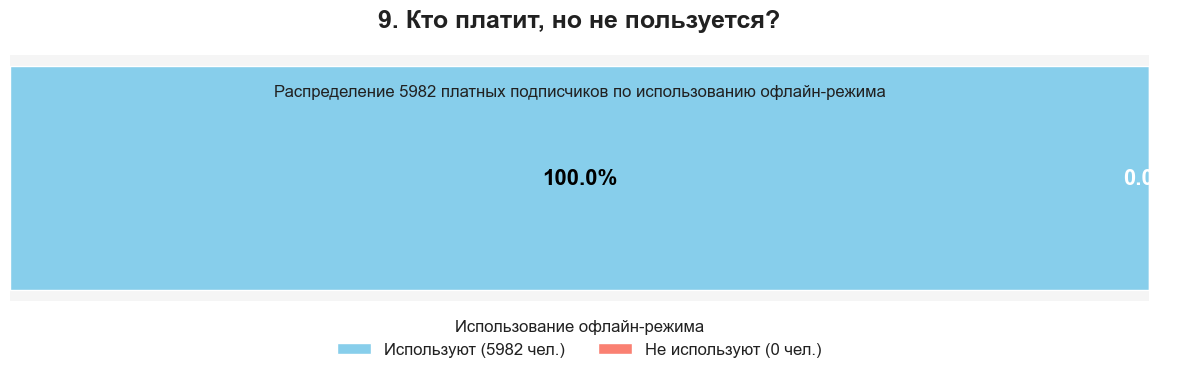

In [ ]:
# --- подготовка данных ---

# фильтруем данные, оставляя только платных подписчиков
df_paid = df[df['subscription_type'] != 'Free'].copy()

# считаем количество пользователей в каждой группе
usage_counts = df_paid['offline_listening'].value_counts()
total_paid_users = len(df_paid)

# рассчитываем проценты
percent_yes = (usage_counts.get(1, 0) / total_paid_users) * 100
percent_no = (usage_counts.get(0, 0) / total_paid_users) * 100


# --- график ---

'''
рисуем 100% stacked bar chart
это как pie chart, только лучше и понятнее
'''
# делаем график невысоким и широким
fig, ax = plt.subplots(figsize=(12, 4)) 

# рисуем синий сегмент для тех, кто использует фичу
ax.barh(
    0, 
    percent_yes, 
    color='skyblue', 
    edgecolor='white', 
    height=0.5, 
    label=f'Используют ({usage_counts.get(1, 0)} чел.)'
    )
# рисуем красный сегмент для тех, кто не использует, начиная с конца синего
ax.barh(
    0, 
    percent_no, 
    left=percent_yes, 
    color='salmon', 
    edgecolor='white', 
    height=0.5, 
    label=f'Не используют ({usage_counts.get(0, 0)} чел.)'
    )


# --- украшаем ---

# заголовок и подзаголовок
ax.set_title("9. Кто платит, но не пользуется?", fontsize=18, fontweight='bold', pad=20)
ax.text(
    0.5, 
    0.85, 
    f"Распределение {total_paid_users} платных подписчиков по использованию офлайн-режима", 
    ha='center', 
    va='center', 
    transform=ax.transAxes, 
    fontsize=12
    )

# добавляем большие цифры с процентами внутрь каждого сегмента
ax.text(percent_yes / 2, 0, f'{percent_yes:.1f}%', ha='center', va='center', color='black', fontsize=16, fontweight='bold')
ax.text(percent_yes + percent_no / 2, 0, f'{percent_no:.1f}%', ha='center', va='center', color='white', fontsize=16, fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xticks([]) # убираем деления на оси x
ax.set_yticks([]) # убираем деления на оси y
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# настраиваем и выносим легенду под график
ax.legend(
    title='Использование офлайн-режима',
    loc='center', 
    bbox_to_anchor=(0.5, -0.15), # положение под графиком
    ncol=2, # в две колонки
    frameon=False, # без рамки
    fontsize=12
)

# подгоняем все элементы
plt.tight_layout()
# отображаем
plt.show()

как мы видем, проблем конкретно с функцией "оффлайн прослушивания" нет у платных пользователей

### 10. Кто уходит и почему?

*   **Идея:** хочу найти группу пользователей, которые активно пользуются сервисом, но все равно уходят. для этого разделю всех на 4 группы по `listening_time` и `skip_rate`.
*   **Зачем?** это поможет найти самую "горячую" точку для вмешательства. эти пользователи еще не ушли, они все еще пытаются найти ценность в продукте. если система сможет вовремя распознать такого пользователя, ему можно предложить что-то особенное (например "кажется, вам не нравятся наши подборки? попробуйте этот плейлист" или "давайте перенастроим ваши вкусы")

/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_1542/2869702763.py:81: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/24/jr600lf178n120v25n50gtvh0000gn/T/ipykernel_1542/2869702763.py:95: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




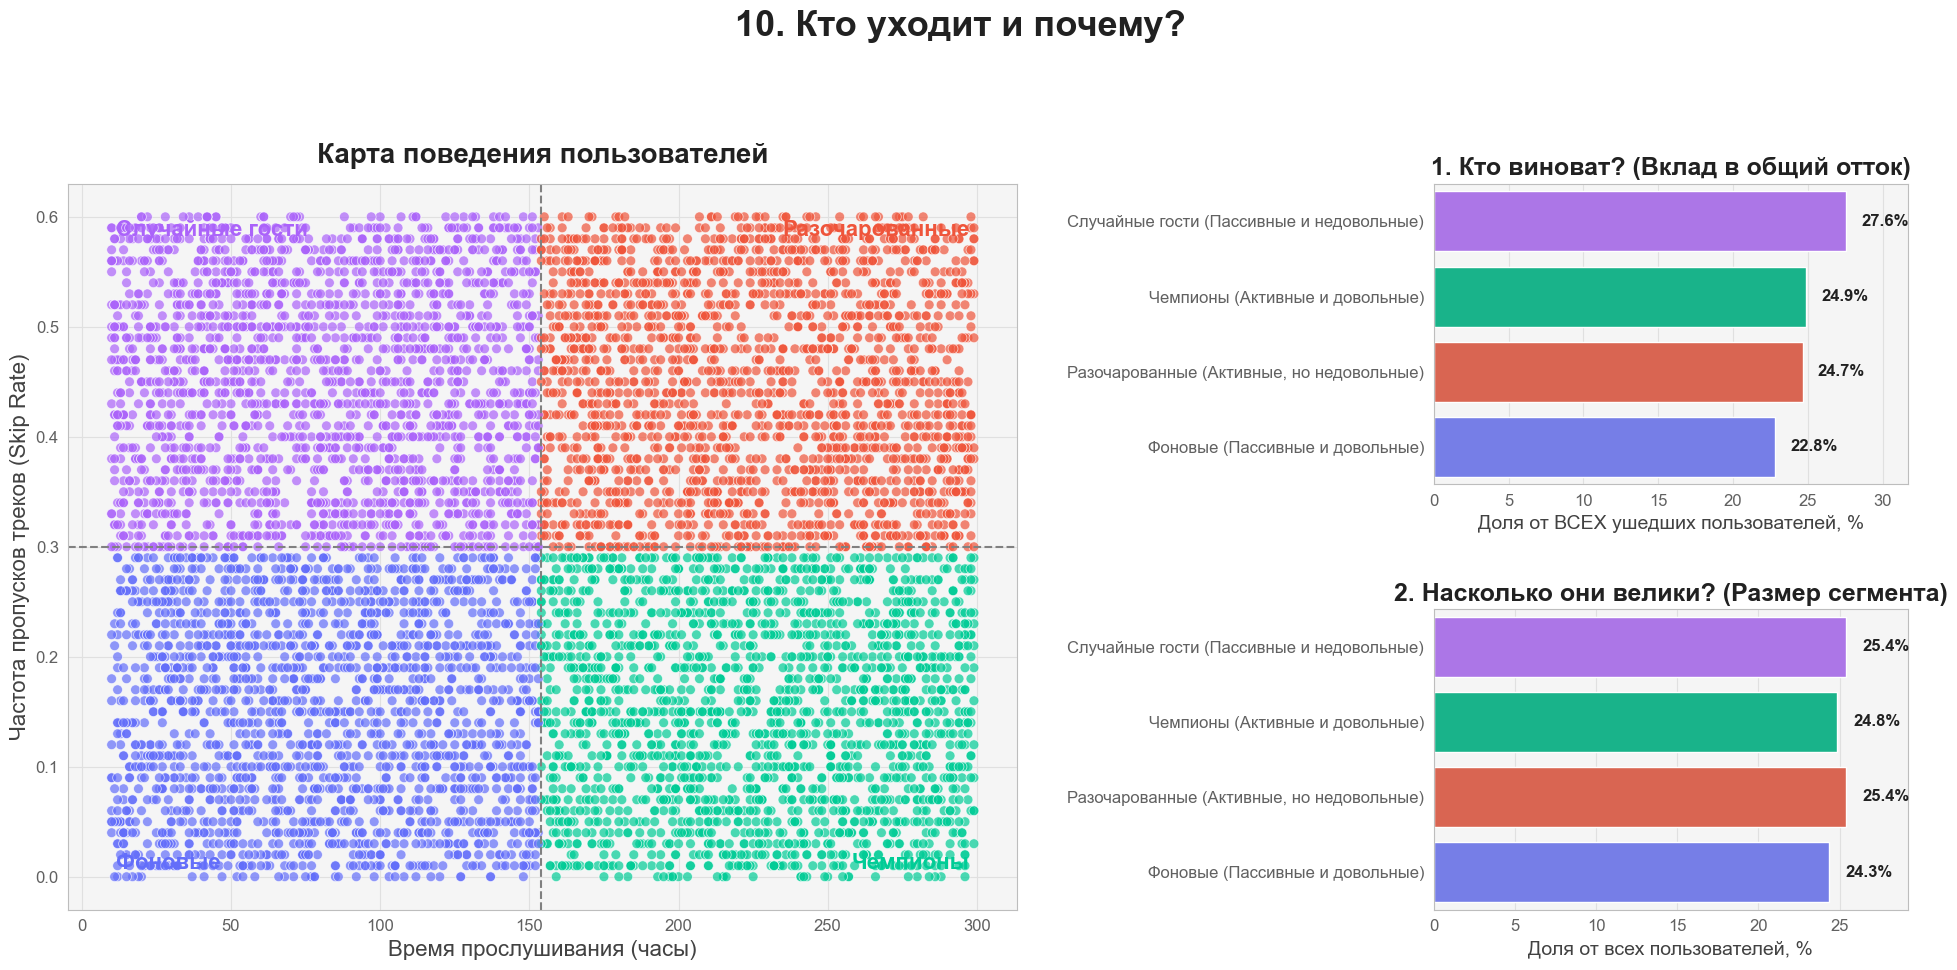

In [55]:
# --- подготовка данных ---

# df_sample = df.sample(n=2000, random_state=42)
df_sample = df.head(8000)

# находим средние значения, они будут границами для наших 4-х групп
median_listening_time = df['listening_time'].median()
median_skip_rate = df['skip_rate'].median()

# функция, которая определяет, в какую из 4-х групп попадает пользователь
def get_segment(row):
    is_active = row['listening_time'] >= median_listening_time
    is_satisfied = row['skip_rate'] < median_skip_rate
    
    if is_active and is_satisfied:
        return 'Чемпионы (Активные и довольные)'
    elif not is_active and is_satisfied:
        return 'Фоновые (Пассивные и довольные)'
    elif is_active and not is_satisfied:
        return 'Разочарованные (Активные, но недовольные)'
    else: # not is_active and not is_satisfied
        return 'Случайные гости (Пассивные и недовольные)'

# создаем новую колонку 'segment' для всех пользователей
df['segment'] = df.apply(get_segment, axis=1)
df_sample['segment'] = df_sample.apply(get_segment, axis=1)

# считаем, какой процент от ВСЕХ ушедших пользователей приходится на каждый сегмент
churners_by_segment = df[df['is_churned'] == 1]['segment'].value_counts()
churn_contribution = (churners_by_segment / df['is_churned'].sum()) * 100

# считаем, какой процент от ВСЕХ пользователей составляет каждый сегмент
segment_size = df['segment'].value_counts(normalize=True) * 100


# --- график ---

'''
создаем сложный макет из 3-х графиков:
- один большой слева
- два маленьких друг под другом справа
'''
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1], height_ratios=[1, 1])

# --- график карта поведения (scatter plot) ---
ax0 = fig.add_subplot(gs[:, 0]) # занимает всю левую часть

# палитра цветов для каждой группы
palette = {
    'Чемпионы (Активные и довольные)': '#00CC96',
    'Фоновые (Пассивные и довольные)': '#636EFA',
    'Разочарованные (Активные, но недовольные)': '#EF553B',
    'Случайные гости (Пассивные и недовольные)': '#AB63FA'
}

# рисуем точки
sns.scatterplot(
    data=df_sample, x='listening_time', y='skip_rate', hue='segment',
    palette=palette, alpha=0.7, s=50, ax=ax0
)
# рисуем разделительные линии
ax0.axvline(median_listening_time, color='grey', linestyle='--', linewidth=1.5)
ax0.axhline(median_skip_rate, color='grey', linestyle='--', linewidth=1.5)

# подписываем каждый из 4-х квадрантов
ax0.text(0.95, 0.95, 'Разочарованные', transform=ax0.transAxes, ha='right', va='top', fontsize=16, fontweight='bold', color=palette['Разочарованные (Активные, но недовольные)'])
ax0.text(0.95, 0.05, 'Чемпионы', transform=ax0.transAxes, ha='right', va='bottom', fontsize=16, fontweight='bold', color=palette['Чемпионы (Активные и довольные)'])
ax0.text(0.05, 0.95, 'Случайные гости', transform=ax0.transAxes, ha='left', va='top', fontsize=16, fontweight='bold', color=palette['Случайные гости (Пассивные и недовольные)'])
ax0.text(0.05, 0.05, 'Фоновые', transform=ax0.transAxes, ha='left', va='bottom', fontsize=16, fontweight='bold', color=palette['Фоновые (Пассивные и довольные)'])

# украшаем
ax0.set_title('Карта поведения пользователей', fontsize=20, fontweight='bold', pad=15)
ax0.set_xlabel('Время прослушивания (часы)', fontsize=16)
ax0.set_ylabel('Частота пропусков треков (Skip Rate)', fontsize=16)
ax0.legend().set_visible(False) # легенда не нужна, все подписано

# --- график Кто виноват? (bar plot) ---
ax1 = fig.add_subplot(gs[0, 1]) # верхний правый

sns.barplot(x=churn_contribution.values, y=churn_contribution.index, palette=[palette.get(label) for label in churn_contribution.index], ax=ax1)
ax1.set_title('1. Кто виноват? (Вклад в общий отток)', fontsize=18, fontweight='bold')
ax1.set_xlabel('Доля от ВСЕХ ушедших пользователей, %', fontsize=14)
ax1.set_ylabel('')
ax1.set_xlim(0, churn_contribution.max() * 1.15)
for p in ax1.patches:
    width = p.get_width()
    ax1.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.1f}%', va='center', fontsize=12, fontweight='bold')

# --- график Насколько они велики? (bar plot) ---
ax2 = fig.add_subplot(gs[1, 1]) # нижний правый

# reindex нужен, чтобы порядок и цвета на графиках б и в совпадали
segment_size_ordered = segment_size.reindex(churn_contribution.index)
sns.barplot(x=segment_size_ordered.values, y=segment_size_ordered.index, palette=[palette.get(label) for label in segment_size_ordered.index], ax=ax2)
ax2.set_title('2. Насколько они велики? (Размер сегмента)', fontsize=18, fontweight='bold')
ax2.set_xlabel('Доля от всех пользователей, %', fontsize=14)
ax2.set_ylabel('')
ax2.set_xlim(0, segment_size_ordered.max() * 1.15)
for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 1, p.get_y() + p.get_height() / 2, f'{width:.1f}%', va='center', fontsize=12, fontweight='bold')


# --- общее украшение ---
fig.suptitle("10. Кто уходит и почему?", fontsize=26, fontweight='bold', y=1.0)
plt.tight_layout(pad=3.0)
plt.show()

как мы видем, всех групп в принципе поровну. так еще и их вклад в отток в принципе равнозначный, что достаточно необычно.

то есть, по какой-то причине даже Чемпионы так же отходят. то есть -- если нам нужно было бы, то нам пришлось бы искать проблему дальше

### 11. Гендерный баланс по странам

*   **Идея:** хочу нарисовать карту мира, где цвет страны будет показывать, какой пол там преобладает среди пользователей.
*   **Зачем?** на самом деле, мне это просто интересно посмотреть. а так, эту информауию можно использовать при составлении локального маркетинга


In [ ]:
# --- подготовка данных ---

# считаем, сколько мужчин, женщин и "других" в каждой стране
gender_by_country = df.groupby(['country', 'gender'])['user_id'].count().unstack().fillna(0)

# считаем, сколько всего юзеров в каждой стране
gender_by_country['total'] = gender_by_country.sum(axis=1)

# находим, какой пол в каждой стране самый многочисленный
gender_by_country['dominant_gender'] = gender_by_country[['Female', 'Male', 'Other']].idxmax(axis=1)

# считаем процент доминирующего пола
gender_by_country['dominance_percentage'] = gender_by_country.apply(
    lambda row: (row[row['dominant_gender']] / row['total']) * 100,
    axis=1
)

# считаем проценты для каждого пола отдельно (это для всплывающей подсказки)
gender_by_country['Female_%'] = (gender_by_country['Female'] / gender_by_country['total']) * 100
gender_by_country['Male_%'] = (gender_by_country['Male'] / gender_by_country['total']) * 100
gender_by_country['Other_%'] = (gender_by_country['Other'] / gender_by_country['total']) * 100

# переводим 2-буквенные коды стран в 3-буквенные, которые понимает plotly
country_iso_map = {
    'CA': 'CAN', 'DE': 'DEU', 'AU': 'AUS', 'US': 'USA', 
    'UK': 'GBR', 'IN': 'IND', 'FR': 'FRA', 'PK': 'PAK'
}
gender_by_country = gender_by_country.reset_index()
gender_by_country['country_iso'] = gender_by_country['country'].map(country_iso_map)

# убираем страны, где мало пользователей, для честной статистики
gender_by_country = gender_by_country[gender_by_country['total'] > 50].copy()


# --- график ---

# рисуем карту мира
fig = px.choropleth(
    gender_by_country,
    locations="country_iso", # страны по 3-буквенному коду
    color="dominant_gender",  # цвет зависит от доминирующего пола
    hover_name="country", # что показывать в заголовке подсказки
    hover_data={ # доп. инфа в подсказке
        'country_iso': False,
        'dominant_gender': True,
        'dominance_percentage': ':.1f',
        'Female_%': ':.1f',
        'Male_%': ':.1f',
        'Other_%': ':.1f',
        'total': True
    },
    color_discrete_map={ # задаем свои цвета
        'Male': '#636EFA',
        'Female': '#EF553B',
        'Other': 'grey'
    },
    labels={ # переименовываем подписи
        'dominant_gender': 'Доминирующий пол',
        'dominance_percentage': '% доминирования',
        'Female_%': 'Женщины (%)',
        'Male_%': 'Мужчины (%)',
        'Other_%': 'Другие (%)',
        'total': 'Всего пользователей'
    }
)


# --- украшаем ---

# настраиваем заголовок и общий вид
fig.update_layout(
    title_text='<b>11. Гендерный баланс по странам</b><br><sup>Цвет страны показывает, какой пол преобладает среди слушателей</sup>',
    title_x=0.5, # заголовок по центру
    font=dict(family="Arial, sans-serif", size=14, color="black"),
    geo=dict(
        showframe=False, # убрать рамку
        showcoastlines=False, # убрать береговые линии
        projection_type='natural earth' # красивая проекция карты
    ),
    legend=dict(
        title='Доминирующий пол',
        orientation="h", # горизонтальная легенда
        yanchor="bottom",
        y=1.02, # над графиком
        xanchor="center",
        x=0.5
    )
)

# отображаем
fig.show()

меня из всего этого списка поражает Пакистан и Индия. либо я имею не те представления об этих страннах, либо там ситуация немного другая, чем описанно в представленных данных

если все нормально с данными, то вот -- я поменял свое мнение И теперь могу это иначе учесть в своих маркетинговых схемах

### 12. Где наша аудитория?

*   **Идея:** хочу сделать рейтинг стран по их доле в общей пользовательской базе, чтобы понять, какие рынки вероятно самые главные.
*   **Зачем?** поможет изменить маркетинг в тех или инных регионах, а так же "точки", которые нельзя терять

In [57]:
# --- подготовка данных ---

# считаем, сколько юзеров в каждой стране
country_counts = df['country'].value_counts()
total_users = len(df)

# создаем новую табличку для удобства
country_share = pd.DataFrame({
    'country': country_counts.index,
    'user_count': country_counts.values
})

# считаем долю каждой страны в процентах
country_share['share_percentage'] = (country_share['user_count'] / total_users) * 100

# сортируем страны от большей к меньшей
country_share = country_share.sort_values('share_percentage', ascending=False)
# считаем накопленную долю (для подсказки при наведении)
country_share['cumulative_share'] = country_share['share_percentage'].cumsum()


# --- график ---

# рисуем столбчатую диаграмму
fig = px.bar(
    country_share,
    x='country', # ось x
    y='share_percentage', # ось y
    text=country_share['share_percentage'].apply(lambda x: f'{x:.1f}%'), # текст на столбцах
    hover_data={ # инфа при наведении
        'country': False,
        'share_percentage': ':.2f',
        'user_count': True,
        'cumulative_share': ':.1f'
    },
    labels={ # переименовываем подписи
        'country': 'Страна',
        'share_percentage': 'Доля в общей аудитории (%)',
        'user_count': 'Количество пользователей',
        'cumulative_share': 'Накопленная доля (%)'
    }
)


# --- украшаем ---

# выделяем топ-3 страны красным цветом для акцента
colors = ['#EF553B', '#EF553B', '#EF553B'] + ['#636EFA'] * (len(country_share) - 3)
fig.update_traces(marker_color=colors, marker_line=dict(width=1, color='black'))

# настраиваем положение текста на столбцах
fig.update_traces(textposition='outside', textfont_size=12)

# настраиваем общий вид
fig.update_layout(
    title_text="<b>12. Где наша аудитория?</b><br><sup>Топ-3 страны составляют почти 40% всей базы</sup>",
    title_x=0.5, # заголовок по центру
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial, sans-serif", size=14, color="black"),
    xaxis=dict(
        title_font=dict(size=16),
        tickfont=dict(size=14),
        showline=True, linewidth=1, linecolor='lightgrey'
    ),
    yaxis=dict(
        title_font=dict(size=16),
        tickfont=dict(size=12),
        showgrid=True, gridwidth=1, gridcolor='lightgrey',
        griddash='dash',
        ticksuffix='%' # добавляем знак % к оси
    ),
    showlegend=False # легенда не нужна
)

# отображаем
fig.show()

хоть мы и выделили лидеров, да

но отравы очень мелкие (буквально 1%), поэтому -- вероятно каких-то конкретных действий к той или инной группе применять не нужно (ну либо нужно, если у нас разные цены на подписки в страннах разные, но такой информацией я не владею)

### 13. Кто на чем сидит?

*   **Идея:** хочу посмотреть, как разные типы подписчиков используют разные устройства. для этого возьму `device_type` и `subscription_type`.
*   **Зачем?** это напрямую покажет на то, куда вкладывать деньги в разработку. если 90% дохода приносят `Premium`-юзеры с мобилок, то мобильное приложение должно хорошо работать и возможно иметь больше интересного функционала.

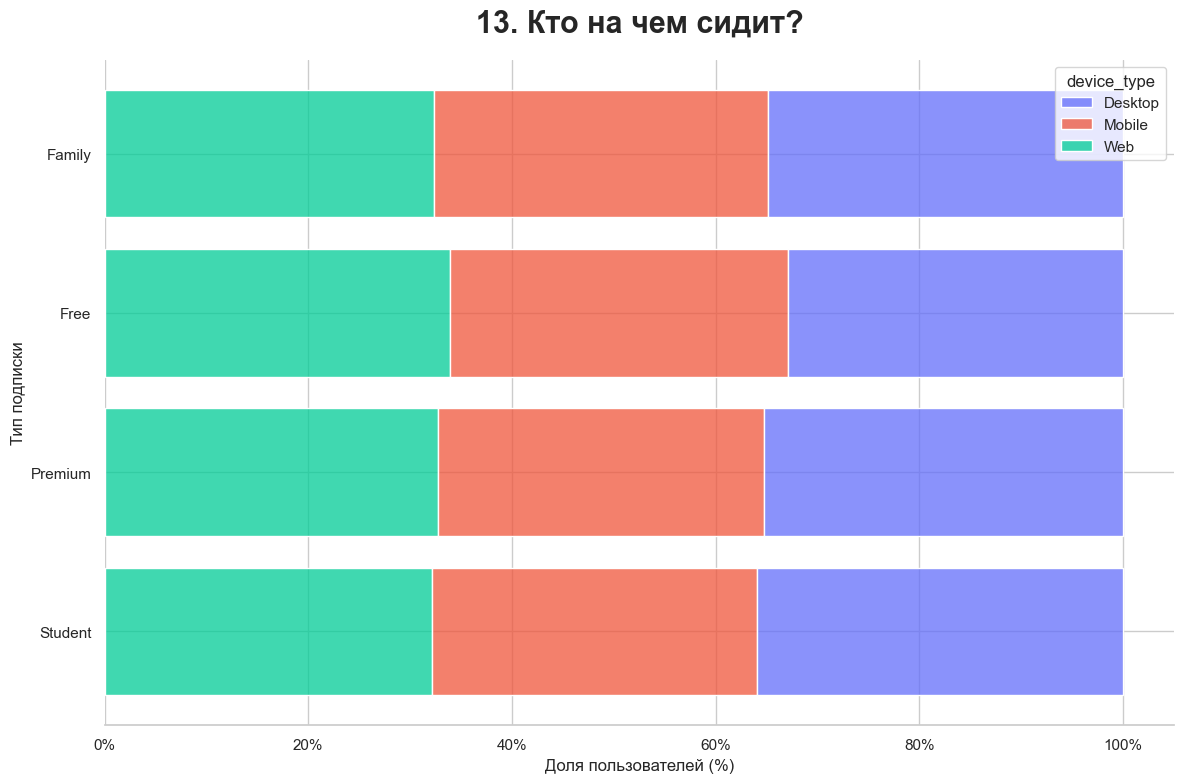

In [64]:
# --- подготовка данных ---
device_dist = pd.crosstab(
    df['subscription_type'], 
    df['device_type'], 
    normalize='index'
) * 100
device_dist_long = device_dist.reset_index().melt(id_vars='subscription_type', var_name='device_type', value_name='percentage')

# --- график ---
plt.figure(figsize=(12, 8))
ax = sns.histplot(
    data=device_dist_long,
    y='subscription_type',
    hue='device_type',
    weights='percentage',
    multiple='stack',
    palette={'Desktop': '#636EFA', 'Mobile': '#EF553B', 'Web': '#00CC96'},
    shrink=0.8
)
# --- украшаем ---
ax.set_title("13. Кто на чем сидит?", fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel('Доля пользователей (%)')
ax.set_ylabel('Тип подписки')
ax.xaxis.set_major_formatter(plt.FuncFormatter('{:.0f}%'.format))
sns.despine(left=True)
plt.tight_layout()
plt.show()

как мы видим, в принципе все пользователи раскинуты равномерно (мне это кажется необычным)

поэтому, по всей видимости нужно в равной степени применять усилия по разработке и поддержке функционала

### 14. Какая платформа теряет пользователей?

*   **Идея:** хочу сравнить процент оттока для каждой из трех платформ (`Mobile`, `Desktop`, `Web`).
*   **Зачем?** если отток на одной из платформ аномально высок, значит, именно в ней есть серьезные проблемы с удобством, скоростью или функциями. это помогает понять, куда направить ресурсы разработчиков.

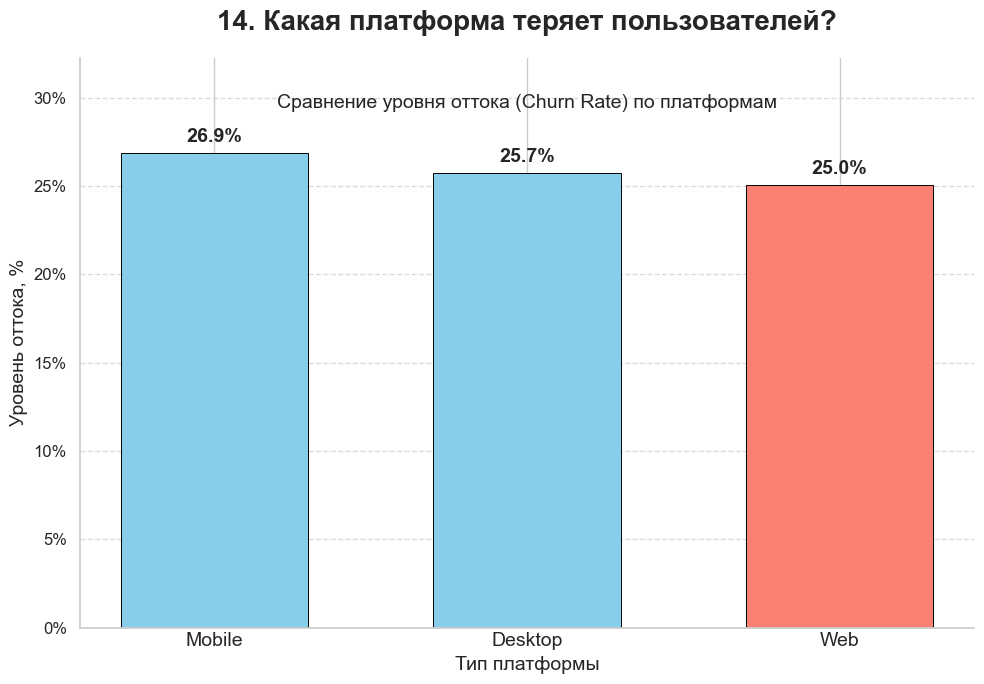

In [63]:
# --- подготовка данных ---

# считаем churn rate (в процентах) для каждого типа устройства
# и сразу сортируем от большего к меньшему
churn_by_device = df.groupby('device_type')['is_churned'].mean().sort_values(ascending=False) * 100


# --- график ---

# инициализируем холст
fig, ax = plt.subplots(figsize=(10, 7))

'''
определяем цвета для столбцов
проблемный 'web' делаем красным, остальные - синими
'''
colors = ['salmon' if dev == 'Web' else 'skyblue' for dev in churn_by_device.index]

# рисуем столбцы
bars = ax.bar(
    churn_by_device.index, # ось x
    churn_by_device.values, # ось y
    color=colors, # наши цвета
    edgecolor='black',
    linewidth=0.7,
    width=0.6 # делаем столбцы чуть уже
)


# --- украшаем ---

# главный заголовок и подзаголовок
ax.set_title("14. Какая платформа теряет пользователей?", fontsize=20, fontweight='bold', pad=20)
ax.text(
    0.5, 
    0.92, 
    "Сравнение уровня оттока (Churn Rate) по платформам", 
    ha='center', 
    va='center', 
    transform=ax.transAxes, 
    fontsize=14
    )

# подписи осей
ax.set_ylabel("Уровень оттока, %", fontsize=14)
ax.set_xlabel("Тип платформы", fontsize=14)
ax.tick_params(axis='x', labelsize=14, length=0)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0, churn_by_device.max() * 1.2) # даем место сверху для подписей

# форматируем ось y в процентах
ax.yaxis.set_major_formatter(plt.FuncFormatter('{:.0f}%'.format))

# убираем лишние рамки и добавляем сетку
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # сетка под столбцами

# добавляем подписи с цифрами на каждый столбец
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# подгоняем элементы
plt.tight_layout()
# отображаем
plt.show()

у нас у всех все одинаково плохо?

видимо мы что-то делаем не так...

### 15. Гендерный выбор тарифа

*   **Идея:** хочу посмотреть, есть ли разница в выборе тарифа между мужчинами и женщинами.
*   **Зачем?** если окажется, что мужчины чаще выбирают `Premium`, а женщины — `Family`, то рекламу этих тарифов можно будет нацеливать на конкретный пол

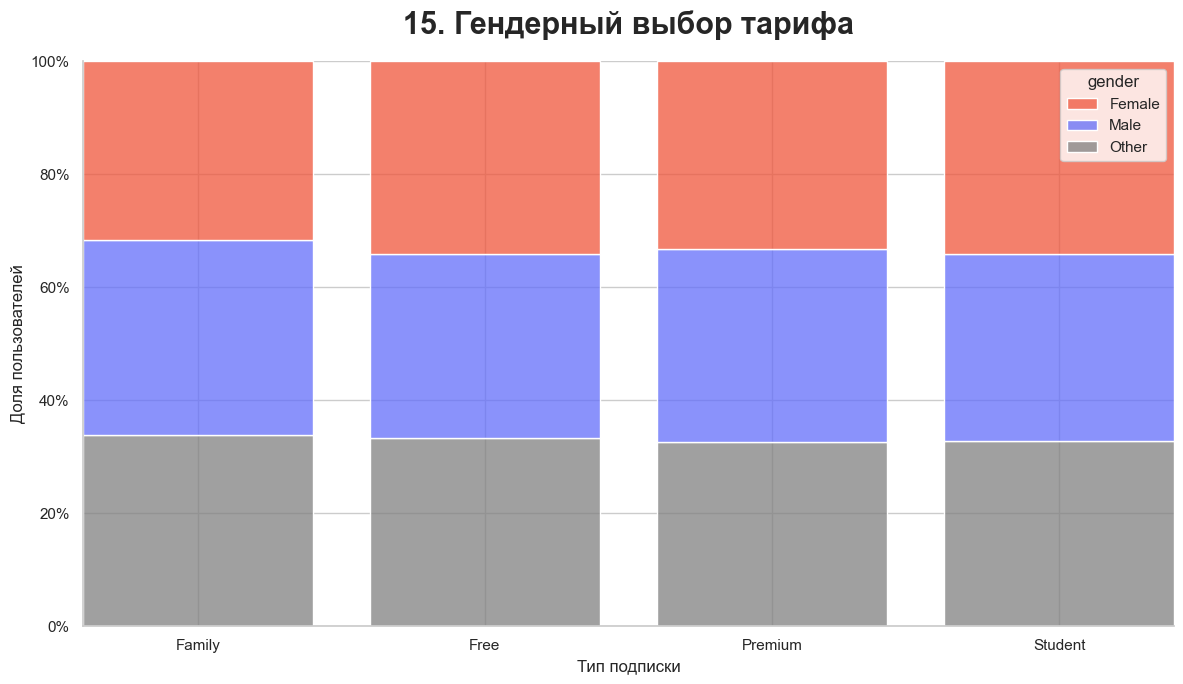

In [65]:
# --- подготовка данных ---
gender_dist_long = df.groupby(['subscription_type', 'gender']).size().reset_index(name='count')

# --- график ---
plt.figure(figsize=(12, 7))
ax = sns.histplot(
    data=gender_dist_long,
    x='subscription_type',
    hue='gender',
    weights='count',
    multiple='fill', # <-- создает 100% stacked bar
    palette={'Male': '#636EFA', 'Female': '#EF553B', 'Other': 'grey'},
    shrink=0.8
)
# --- украшаем ---
ax.set_title("15. Гендерный выбор тарифа", fontsize=22, fontweight='bold', pad=20)
ax.set_xlabel("Тип подписки")
ax.set_ylabel("Доля пользователей")
ax.yaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
sns.despine()
plt.tight_layout()
plt.show()

всех и всего по ровну

вероятно нет необходимости проводить какие-то особые программы